# Trimming Messages

### Set the OpenAI API Key as an Environment Variable

In [1]:
%load_ext dotenv
%dotenv
%load_ext mypy_ipython

### Import Relevant Classes and Functions

In [2]:
from langgraph.graph import START, END, StateGraph, add_messages, MessagesState
from typing_extensions import TypedDict
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.messages import AIMessage, HumanMessage, BaseMessage, RemoveMessage
from collections.abc import Sequence
from typing import Literal, Annotated

### Define the Nodes

In [3]:
chat = ChatOpenAI(model = "gpt-4o", 
                  seed = 365, 
                  temperature = 0, 
                  max_completion_tokens = 100)

In [4]:
def ask_question(state: MessagesState) -> MessagesState:
    
    print(f"\n-------> ENTERING ask_question:")
    for i in state["messages"]:
        i.pretty_print()
    
    question = "What is your question?"
    print(question)
    
    return MessagesState(messages = [AIMessage(question), HumanMessage(input())])


In [5]:
def chatbot(state: MessagesState) -> MessagesState:
    
    print(f"\n-------> ENTERING chatbot:")
    for i in state["messages"]:
        i.pretty_print()
    
    response = chat.invoke(state["messages"])
    response.pretty_print()
    
    return MessagesState(messages = [response])

In [6]:
def ask_another_question(state: MessagesState) -> MessagesState:
    
    print(f"\n-------> ENTERING ask_another_question:")
    for i in state["messages"]:
        i.pretty_print()
    
    question = "Would you like to ask one more question (yes/no)?"
    print(question)
    
    return MessagesState(messages = [AIMessage(question), HumanMessage(input())])

In [8]:
def trim_messages(state: MessagesState) -> MessagesState:
    print(f"\n-------> ENTERING trim_messages:")

    remove_messages = [RemoveMessage(id = i.id) for i in state["messages"][:-5]]

    return MessagesState(messages = remove_messages)

### Define the Routing Function

In [10]:
def routing_function(state: MessagesState) -> Literal["trim_messages", "__end__"]:
    
    if state["messages"][-1].content == "yes":
        return "trim_messages"
    else:
        return "__end__"

### Define the Graph

In [11]:
graph = StateGraph(MessagesState)

In [12]:
graph.add_node("ask_question", ask_question)
graph.add_node("chatbot", chatbot)
graph.add_node("ask_another_question", ask_another_question)
graph.add_node("trim_messages", trim_messages)

graph.add_edge(START, "ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "ask_another_question")
graph.add_conditional_edges(source = "ask_another_question", 
                            path = routing_function)
graph.add_edge("trim_messages", "ask_question")

In [13]:
graph_compiled = graph.compile()

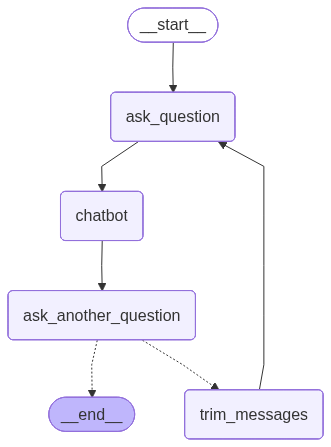

In [14]:
graph_compiled

### Test the Graph

In [15]:
graph_compiled.invoke(MessagesState(messages = []))


-------> ENTERING ask_question:
What is your question?


 Could you give me a grook by Piet Hein ?



-------> ENTERING chatbot:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Could you give me a grook by Piet Hein ?
================================== Ai Message ==================================

Certainly! Here is a well-known grook by Piet Hein:

**"The Road to Wisdom"**

The road to wisdom?—Well, it's plain
and simple to express:
Err
and err
and err again,
but less
and less
and less.

Piet Hein's grooks are known for their brevity and depth, often capturing profound truths in just a few lines.

-------> ENTERING ask_another_question:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Could you give me a grook by Piet Hein ?
================================== Ai Message ==================================

Certa

 yes



-------> ENTERING trim_messages:

-------> ENTERING ask_question:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Could you give me a grook by Piet Hein ?
================================== Ai Message ==================================

Certainly! Here is a well-known grook by Piet Hein:

**"The Road to Wisdom"**

The road to wisdom?—Well, it's plain
and simple to express:
Err
and err
and err again,
but less
and less
and less.

Piet Hein's grooks are known for their brevity and depth, often capturing profound truths in just a few lines.
================================== Ai Message ==================================

Would you like to ask one more question (yes/no)?
================================ Human Message =================================

yes
What is your question?


...


-------> ENTERING trim_messages:

-------> ENTERING ask_question:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

What else did he do ?
================================== Ai Message ==================================

Piet Hein was a remarkably versatile individual with contributions across various fields:

1. **Poetry**: He is best known for his short, witty poems called "gruks" or "grooks," which often contain philosophical insights and humor.

2. **Mathematics and Science**: Hein had a keen interest in mathematics and science. He is credited with inventing the "superellipse," a geometric shape that blends properties of an ellipse and a rectangle. This shape has been used in architecture
================================== Ai Message ==================================

Would you like to ask one more question (yes/no)?
=============================

 Do you remember the grook you told me ?



-------> ENTERING chatbot:
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

What else did he do ?
================================== Ai Message ==================================

Piet Hein was a remarkably versatile individual with contributions across various fields:

1. **Poetry**: He is best known for his short, witty poems called "gruks" or "grooks," which often contain philosophical insights and humor.

2. **Mathematics and Science**: Hein had a keen interest in mathematics and science. He is credited with inventing the "superellipse," a geometric shape that blends properties of an ellipse and a rectangle. This shape has been used in architecture
================================== Ai Message ==================================

Would you like to ask one more question (yes/no)?
================================ Human Message =====================

 no


{'messages': [AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='57700168-eccd-4f6d-b574-ac3003410009'),
  HumanMessage(content='What else did he do ?', additional_kwargs={}, response_metadata={}, id='365c5097-3ff9-4b81-8ae4-8a2071e67a0c'),
  AIMessage(content='Piet Hein was a remarkably versatile individual with contributions across various fields:\n\n1. **Poetry**: He is best known for his short, witty poems called "gruks" or "grooks," which often contain philosophical insights and humor.\n\n2. **Mathematics and Science**: Hein had a keen interest in mathematics and science. He is credited with inventing the "superellipse," a geometric shape that blends properties of an ellipse and a rectangle. This shape has been used in architecture', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 100, 'prompt_tokens': 107, 'total_tokens': 207, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio